# Loan Approval Prediction - Analysis Notebook

This notebook follows the project plan phases 1-7 on the
`data/loan_data.csv` dataset:

| Phase | Topic |
| ----- | ----- |
| 1 | Understand the dataset |
| 2 | Exploratory Data Analysis |
| 3 | Data preprocessing |
| 4 | Train multiple models |
| 5 | Evaluate the models |
| 6 | Select the best model |
| 7 | Save the model |

The reproducible script version of this notebook is `src/train.py`; run it with
`python -m src.train`.

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## Phase 1 - Understand the dataset

Questions: how many rows/features, which columns are numerical vs categorical,
are there missing values, and how are approved/rejected loans distributed?

In [2]:
df = pd.read_csv("../data/loan_data.csv")

# The raw file stores every column name AND every categorical value with a
# leading space -> strip them so the documented names can be used.
df.columns = [column.strip() for column in df.columns]
for column in df.columns:
    if df[column].dtype == "object":
        df[column] = df[column].str.strip()

# `loan_id` is a unique identifier with no predictive value.
df = df.drop(columns=["loan_id"])

df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.info()

Rows: 4269
Columns: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4269 non-null   int64 
 1   education                 4269 non-null   object
 2   self_employed             4269 non-null   object
 3   income_annum              4269 non-null   int64 
 4   loan_amount               4269 non-null   int64 
 5   loan_term                 4269 non-null   int64 
 6   cibil_score               4269 non-null   int64 
 7   residential_assets_value  4269 non-null   int64 
 8   commercial_assets_value   4269 non-null   int64 
 9   luxury_assets_value       4269 non-null   int64 
 10  bank_asset_value          4269 non-null   int64 
 11  loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_dependents,"4,269.00",2.50,1.70,0.00,1.00,3.00,4.00,5.00
income_annum,"4,269.00","5,059,123.92","2,806,839.83","200,000.00","2,700,000.00","5,100,000.00","7,500,000.00","9,900,000.00"
loan_amount,"4,269.00","15,133,450.46","9,043,362.98","300,000.00","7,700,000.00","14,500,000.00","21,500,000.00","39,500,000.00"
loan_term,"4,269.00",10.90,5.71,2.00,6.00,10.00,16.00,20.00
cibil_score,"4,269.00",599.94,172.43,300.00,453.00,600.00,748.00,900.00
residential_assets_value,"4,269.00","7,472,616.54","6,503,636.59","-100,000.00","2,200,000.00","5,600,000.00","11,300,000.00","29,100,000.00"
commercial_assets_value,"4,269.00","4,973,155.31","4,388,966.09",0.00,"1,300,000.00","3,700,000.00","7,600,000.00","19,400,000.00"
luxury_assets_value,"4,269.00","15,126,305.93","9,103,753.67","300,000.00","7,500,000.00","14,600,000.00","21,700,000.00","39,200,000.00"
bank_asset_value,"4,269.00","4,976,692.43","3,250,185.31",0.00,"2,300,000.00","4,600,000.00","7,100,000.00","14,700,000.00"


In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values per column:")
print(missing[missing.gt(0)].to_string() if missing.gt(0).any() else "None")
print(f"Duplicated rows: {df.duplicated().sum()}")
print(f"Numerical features: {df.select_dtypes('number').columns.tolist()}")
print(f"Categorical features: {df.select_dtypes('object').columns.tolist()}")

Missing values per column:
None
Duplicated rows: 0
Numerical features: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Categorical features: ['education', 'self_employed', 'loan_status']


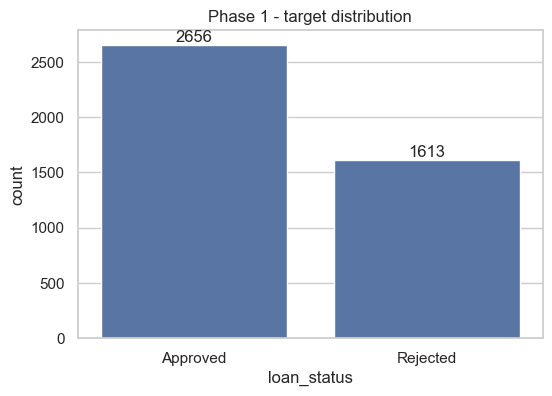

loan_status
Approved   0.62
Rejected   0.38


In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="loan_status", ax=ax)
ax.set_title("Phase 1 - target distribution")
for patch, value in zip(ax.patches, df["loan_status"].value_counts().sort_index()):
    ax.annotate(str(value), (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                ha="center", va="bottom")
plt.show()

print(df["loan_status"].value_counts(normalize=True).round(4).to_string())

## Phase 2 - Exploratory Data Analysis

**Q1 - Does the CIBIL score relate to loan approval?**

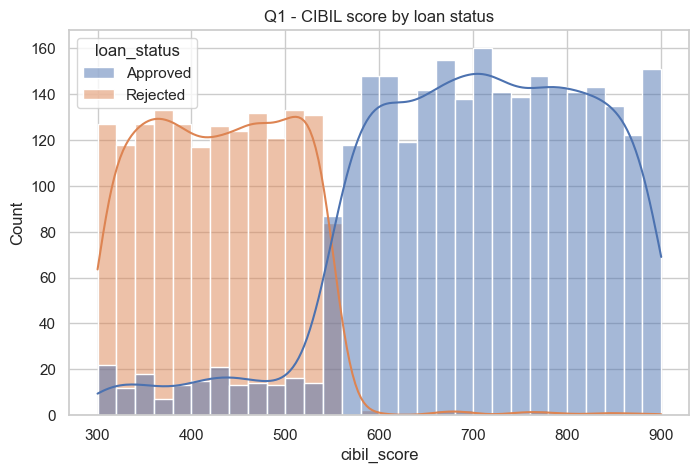

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x="cibil_score", hue="loan_status", bins=30, kde=True, ax=ax)
ax.set_title("Q1 - CIBIL score by loan status")
plt.show()

**Q2 - Does income affect loan approval?**

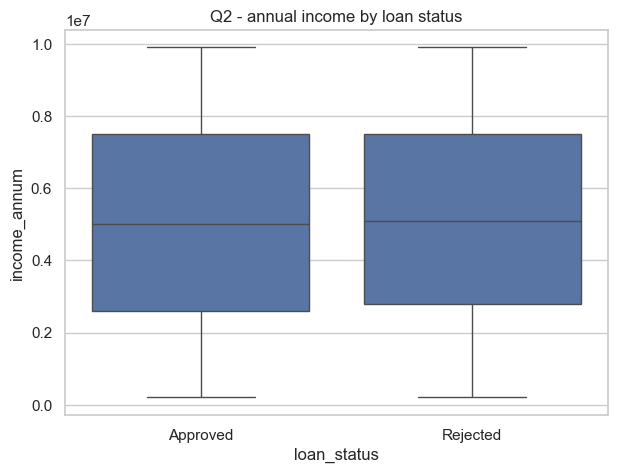

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="loan_status", y="income_annum", ax=ax)
ax.set_title("Q2 - annual income by loan status")
plt.show()

**Q3 - Does the requested loan amount affect approval?**

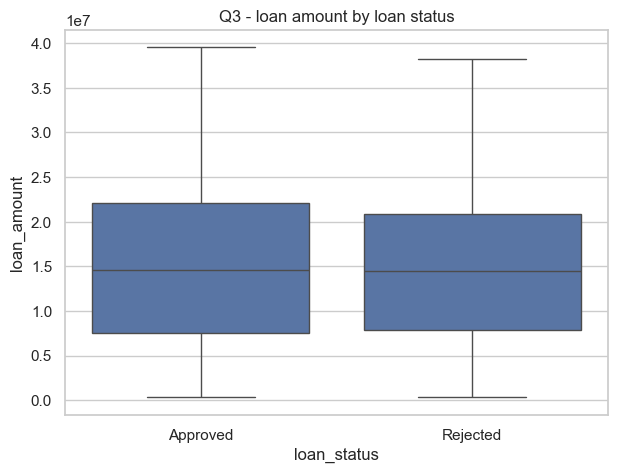

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="loan_status", y="loan_amount", ax=ax)
ax.set_title("Q3 - loan amount by loan status")
plt.show()

**Q4 - Do education / self-employment matter?**

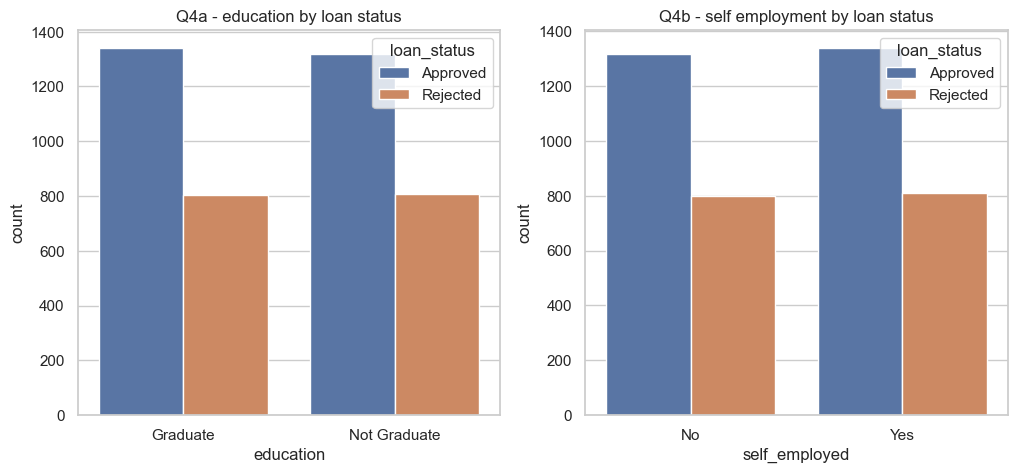

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x="education", hue="loan_status", ax=axes[0])
axes[0].set_title("Q4a - education by loan status")
sns.countplot(data=df, x="self_employed", hue="loan_status", ax=axes[1])
axes[1].set_title("Q4b - self employment by loan status")
plt.show()

**Q5 - Are there class imbalance problems? / Which features correlate with the target?**

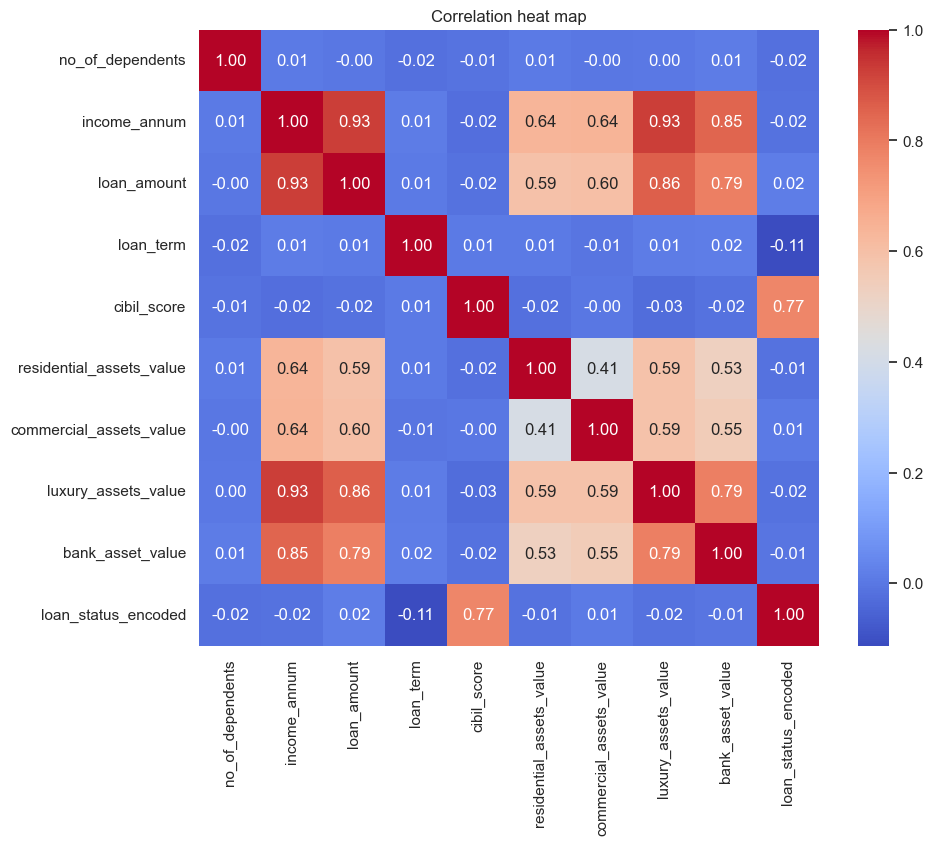

Absolute correlation with the target:
cibil_score                0.77
loan_term                  0.11
no_of_dependents           0.02
loan_amount                0.02
luxury_assets_value        0.02
income_annum               0.02
residential_assets_value   0.01
commercial_assets_value    0.01
bank_asset_value           0.01


In [11]:
numeric_features = [
    "no_of_dependents", "income_annum", "loan_amount", "loan_term",
    "cibil_score", "residential_assets_value", "commercial_assets_value",
    "luxury_assets_value", "bank_asset_value",
]
categorical_features = ["education", "self_employed"]

df["loan_status_encoded"] = df["loan_status"].map({"Rejected": 0, "Approved": 1})
correlation = df[numeric_features + ["loan_status_encoded"]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation heat map")
plt.show()

print("Absolute correlation with the target:")
print(
    correlation["loan_status_encoded"]
    .drop("loan_status_encoded")
    .abs()
    .sort_values(ascending=False)
    .to_string()
)

## Phase 3 - Data preprocessing

Models need numbers, so categorical values are one-hot encoded and numerical
values are standardised:

$$ z = \frac{x - \mu}{\sigma} $$

Both live inside a `ColumnTransformer` which is wrapped together with the
classifier in a `Pipeline`. The pipeline is fitted on the training split only,
so the identical statistics are reused at prediction time (no data leakage).

In [12]:
X = df[numeric_features + categorical_features]
y = df["loan_status_encoded"]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("categorical", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print(f"Train balance: {y_train.value_counts().sort_index().to_dict()}")

Train: (3415, 11)   Test: (854, 11)
Train balance: {0: 1290, 1: 2125}


## Phase 4 - Train multiple models

* **Logistic Regression** - simple, interpretable baseline
* **Decision Tree** - learns non-linear splits
* **Random Forest** - ensemble of trees, usually the strongest of the three

In [13]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
    ),
}

pipelines = {}
for name, estimator in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", estimator)])
    pipeline.fit(X_train, y_train)
    pipelines[name] = pipeline
    print(f"trained: {name}")

trained: Logistic Regression
trained: Decision Tree
trained: Random Forest


## Phase 5 - Evaluate the models

Accuracy alone hides *which* mistakes are made, so precision, recall, F1 and the
confusion matrix are all reported.

In [14]:
results = {}
for name, pipeline in pipelines.items():
    y_pred = pipeline.predict(X_test)
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    }

comparison = pd.DataFrame(results).T.sort_values("f1", ascending=False)
comparison

,accuracy,precision,recall,f1
Random Forest,0.98,0.98,0.99,0.99
Decision Tree,0.98,0.99,0.97,0.98
Logistic Regression,0.92,0.96,0.92,0.94


In [15]:
for name, pipeline in pipelines.items():
    print(f"=== {name} ===")
    print(classification_report(
        y_test, pipeline.predict(X_test), target_names=["Rejected", "Approved"]
    ))

=== Logistic Regression ===
              precision    recall  f1-score   support

    Rejected       0.88      0.93      0.90       323
    Approved       0.96      0.92      0.94       531

    accuracy                           0.92       854
   macro avg       0.92      0.92      0.92       854
weighted avg       0.93      0.92      0.92       854

=== Decision Tree ===
              precision    recall  f1-score   support

    Rejected       0.96      0.98      0.97       323
    Approved       0.99      0.97      0.98       531

    accuracy                           0.98       854
   macro avg       0.97      0.98      0.97       854
weighted avg       0.98      0.98      0.98       854

=== Random Forest ===
              precision    recall  f1-score   support

    Rejected       0.98      0.98      0.98       323
    Approved       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
we

Confusion matrix for every model - rows are actual outcomes, columns are predictions.

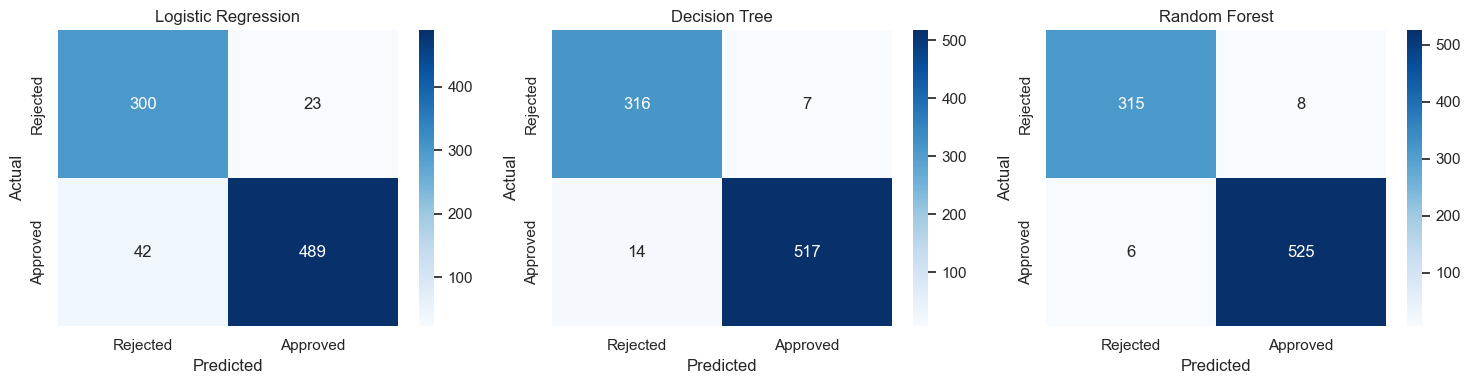

In [16]:
fig, axes = plt.subplots(1, len(pipelines), figsize=(5 * len(pipelines), 4))
for ax, (name, pipeline) in zip(axes, pipelines.items()):
    matrix = confusion_matrix(y_test, pipeline.predict(X_test), labels=[0, 1])
    sns.heatmap(
        matrix, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Rejected", "Approved"],
        yticklabels=["Rejected", "Approved"], ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## Phase 6 - Select the best model

Selection is based on the measured F1 score rather than accuracy alone, because the cost of a wrong approval is not the same as the cost of a wrong rejection.

In [17]:
best_name = str(comparison.index[0])
best_pipeline = pipelines[best_name]
print(f"Best model: {best_name}")
print(comparison.loc[best_name].to_string())

Best model: Random Forest
accuracy    0.98
precision   0.98
recall      0.99
f1          0.99


## Phase 7 - Save the model

The saved object contains BOTH the preprocessing and the classifier, so the API can never apply a transformation that differs from the one used during training.

In [18]:
joblib.dump(best_pipeline, "../models/loan_model.pkl")
print(f"saved ../models/loan_model.pkl ({best_name})")
print(results[best_name])

saved ../models/loan_model.pkl (Random Forest)
{'accuracy': 0.9836065573770492, 'precision': 0.9849906191369606, 'recall': 0.9887005649717514, 'f1': 0.9868421052631579}


## Conclusion

* `cibil_score` is by far the strongest signal in this dataset, followed by
  `loan_term`; the asset and income columns matter much less.
* Education and self-employment are distributed almost evenly across approved
  and rejected applications, so they add little on their own.
* The Random Forest ensemble achieved the best F1 score, with the Decision Tree
  close behind; Logistic Regression under-performed because the CIBIL-score
  decision boundary is highly non-linear.
* Next step: serve this pipeline through FastAPI (`app/main.py`) and the web
  form in `static/`.